In [20]:
# Step 1: Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import IsolationForest


# Display a message
print("All libraries imported successfully!")

All libraries imported successfully!


In [21]:
# Import the transaction dataset

df = pd.read_csv("transactions.csv")

In [22]:
# Display the dataset

df

,Transaction_ID,Customer,Amount,Transaction_Count
0,T0001,Customer_052,90599.72,2
1,T0002,Customer_093,77375.96,1
2,T0003,Customer_015,26857.10,2
3,T0004,Customer_072,64706.34,1
4,T0005,Customer_061,59777.20,2
...,...,...,...,...
2495,T2496,Customer_046,99692.47,7
2496,T2497,Customer_019,18753.51,1
2497,T2498,Customer_068,59617.12,5
2498,T2499,Customer_090,41431.77,3


In [23]:
# Display the first five records

print("First five records")

print(df.head())


First five records
  Transaction_ID      Customer    Amount  Transaction_Count
0          T0001  Customer_052  90599.72                  2
1          T0002  Customer_093  77375.96                  1
2          T0003  Customer_015  26857.10                  2
3          T0004  Customer_072  64706.34                  1
4          T0005  Customer_061  59777.20                  2


In [24]:
# Display the last five records

print("Last five records")

print(df.tail())

Last five records
     Transaction_ID      Customer    Amount  Transaction_Count
2495          T2496  Customer_046  99692.47                  7
2496          T2497  Customer_019  18753.51                  1
2497          T2498  Customer_068  59617.12                  5
2498          T2499  Customer_090  41431.77                  3
2499          T2500  Customer_042  13075.45                  6


In [25]:
# Display the number of rows and columns

print("Dataset shape:")

print(df.shape)


Dataset shape:
(2500, 4)


In [26]:
# Display the column names

print("Column names:")

print(df.columns)

Column names:
Index(['Transaction_ID', 'Customer', 'Amount', 'Transaction_Count'], dtype='object')


In [27]:
# Display the number of records

print("Total records:", len(df))

Total records: 2500


In [28]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Transaction_ID     2500 non-null   object 
 1   Customer           2500 non-null   object 
 2   Amount             2500 non-null   float64
 3   Transaction_Count  2500 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 78.3+ KB


In [29]:
# Display statistical information

print(df.describe())

             Amount  Transaction_Count
count   2500.000000        2500.000000
mean   50390.357996           4.098400
std    28884.406972           2.081934
min    -4971.400000           1.000000
25%    25022.912500           2.000000
50%    51645.575000           4.000000
75%    75486.137500           6.000000
max    99971.520000          11.000000


In [30]:
# Check missing values

print("Missing values in each column")

print(df.isnull().sum())

Missing values in each column
Transaction_ID       0
Customer             0
Amount               0
Transaction_Count    0
dtype: int64


In [31]:
# Check duplicate records

print("Duplicate records:")

print(df.duplicated().sum())

Duplicate records:
0


In [32]:
# Remove duplicate records

df = df.drop_duplicates()

In [33]:
df

,Transaction_ID,Customer,Amount,Transaction_Count
0,T0001,Customer_052,90599.72,2
1,T0002,Customer_093,77375.96,1
2,T0003,Customer_015,26857.10,2
3,T0004,Customer_072,64706.34,1
4,T0005,Customer_061,59777.20,2
...,...,...,...,...
2495,T2496,Customer_046,99692.47,7
2496,T2497,Customer_019,18753.51,1
2497,T2498,Customer_068,59617.12,5
2498,T2499,Customer_090,41431.77,3


In [34]:
# Display the cleaned dataset size

print("Dataset after removing duplicates:")

print(df.shape)

Dataset after removing duplicates:
(2500, 4)


In [35]:
# Remove extra spaces from column names

df.columns = df.columns.str.strip()

In [36]:
# Display column names

print(df.columns)

Index(['Transaction_ID', 'Customer', 'Amount', 'Transaction_Count'], dtype='object')


In [37]:
# Remove extra spaces from text columns

df["Transaction_ID"] = (
    df["Transaction_ID"].astype("string").str.strip()
)

df["Customer"] = (
    df["Customer"].astype("string").str.strip()
)


In [38]:
# Display the cleaned data

print(df.head())

print("Text data cleaned successfully")

  Transaction_ID      Customer    Amount  Transaction_Count
0          T0001  Customer_052  90599.72                  2
1          T0002  Customer_093  77375.96                  1
2          T0003  Customer_015  26857.10                  2
3          T0004  Customer_072  64706.34                  1
4          T0005  Customer_061  59777.20                  2
Text data cleaned successfully


In [39]:
# Convert Amount into numeric format

df["Amount"] = pd.to_numeric(
    df["Amount"],
    errors="coerce"
)


In [40]:
# Convert Transaction_Count into numeric format

df["Transaction_Count"] = pd.to_numeric(
    df["Transaction_Count"],
    errors="coerce"
)


In [41]:
# Check data types

print(df.dtypes)

Transaction_ID       string[python]
Customer             string[python]
Amount                      float64
Transaction_Count             int64
dtype: object


In [42]:
# Check missing values

print(df.isnull().sum())

Transaction_ID       0
Customer             0
Amount               0
Transaction_Count    0
dtype: int64


In [43]:
# Remove rows with missing important values

df = df.dropna(
    subset=[
        "Transaction_ID",
        "Customer",
        "Amount",
        "Transaction_Count"
    ]
)


In [44]:
# Remove invalid transaction amounts

df = df[df["Amount"] >= 0]


In [45]:
# Remove invalid transaction counts

df = df[df["Transaction_Count"] >= 0]

In [46]:
# Display the cleaned dataset

print(df.head())

print("Data cleaning completed successfully")

  Transaction_ID      Customer    Amount  Transaction_Count
0          T0001  Customer_052  90599.72                  2
1          T0002  Customer_093  77375.96                  1
2          T0003  Customer_015  26857.10                  2
3          T0004  Customer_072  64706.34                  1
4          T0005  Customer_061  59777.20                  2
Data cleaning completed successfully


In [47]:
# Calculate total transaction amount

total_amount = df["Amount"].sum()

In [48]:
# Display total amount

print("Total Transaction Amount:", total_amount)

Total Transaction Amount: 126028391.06


In [49]:
# Calculate average transaction amount

average_amount = df["Amount"].mean()

# Display average amount

print("Average Transaction Amount:", average_amount)

Average Transaction Amount: 50817.89962096774


In [50]:
# Find the maximum transaction amount

maximum_amount = df["Amount"].max()

# Find the minimum transaction amount

minimum_amount = df["Amount"].min()

# Display the results

print("Maximum Transaction:", maximum_amount)

print("Minimum Transaction:", minimum_amount)

Maximum Transaction: 99971.52
Minimum Transaction: 518.75


In [51]:
# Calculate total number of transactions

total_transactions = len(df)

# Calculate total transaction count

transaction_count = df["Transaction_Count"].sum()

# Display results

print("Total Transaction Records:", total_transactions)

print("Total Transaction Count:", transaction_count)

Total Transaction Records: 2480
Total Transaction Count: 10170


In [52]:
# Create a transaction classification function

def classify_transaction(amount):

    if amount >= 50000:
        return "High Value"

    elif amount >= 10000:
        return "Medium Value"

    else:
        return "Low Value"


# Apply the function

df["Transaction_Category"] = (
    df["Amount"].apply(classify_transaction)
)

# Display the result

print(df.head())

  Transaction_ID      Customer    Amount  Transaction_Count  \
0          T0001  Customer_052  90599.72                  2   
1          T0002  Customer_093  77375.96                  1   
2          T0003  Customer_015  26857.10                  2   
3          T0004  Customer_072  64706.34                  1   
4          T0005  Customer_061  59777.20                  2   

  Transaction_Category  
0           High Value  
1           High Value  
2         Medium Value  
3           High Value  
4           High Value  


In [53]:
# Group transactions by customer

customer_summary = df.groupby("Customer").agg(
    Total_Amount=("Amount", "sum"),
    Average_Amount=("Amount", "mean"),
    Number_of_Transactions=("Transaction_ID", "count")
)

# Display customer summary

print(customer_summary.head(10))

              Total_Amount  Average_Amount  Number_of_Transactions
Customer                                                          
Customer_001    1434361.08    43465.487273                      33
Customer_002    1409268.03    48595.449310                      29
Customer_003    1477905.26    54737.231852                      27
Customer_004     899339.91    40879.086818                      22
Customer_005    1532270.08    54723.931429                      28
Customer_006    1319429.97    54976.248750                      24
Customer_007    1206789.29    54854.058636                      22
Customer_008    1450974.81    48365.827000                      30
Customer_009    1351022.47    51962.402692                      26
Customer_010     939876.05    52215.336111                      18


In [54]:
# Calculate category-wise transaction totals

category_summary = df.groupby(
    "Transaction_Category"
)["Amount"].agg(
    ["sum", "mean", "count"]
)

# Display category summary

print(category_summary)

                              sum          mean  count
Transaction_Category                                  
High Value            96233852.11  74599.885357   1290
Low Value              1216587.28   5176.967149    235
Medium Value          28577951.67  29924.556723    955


In [55]:
# Perform department-wise analysis

if "department" in df.columns:

    department_summary = df.groupby(
        "department"
    )["amount"].agg(
        ["sum", "mean", "count"]
    )

    print(department_summary)

else:
    print("Department column not found")

Department column not found


In [56]:
# Calculate total transaction amount for each customer

customer_amount = df.groupby(
    "Customer"
)["Amount"].sum()

# Display the top ten customers by transaction amount

top_customers = customer_amount.sort_values(
    ascending=False
).head(10)

print(top_customers)

Customer
Customer_062    1974717.13
Customer_033    1867777.39
Customer_092    1848630.10
Customer_059    1733635.32
Customer_089    1723069.86
Customer_075    1702156.25
Customer_090    1679184.56
Customer_047    1618270.92
Customer_051    1582721.01
Customer_098    1580619.07
Name: Amount, dtype: float64


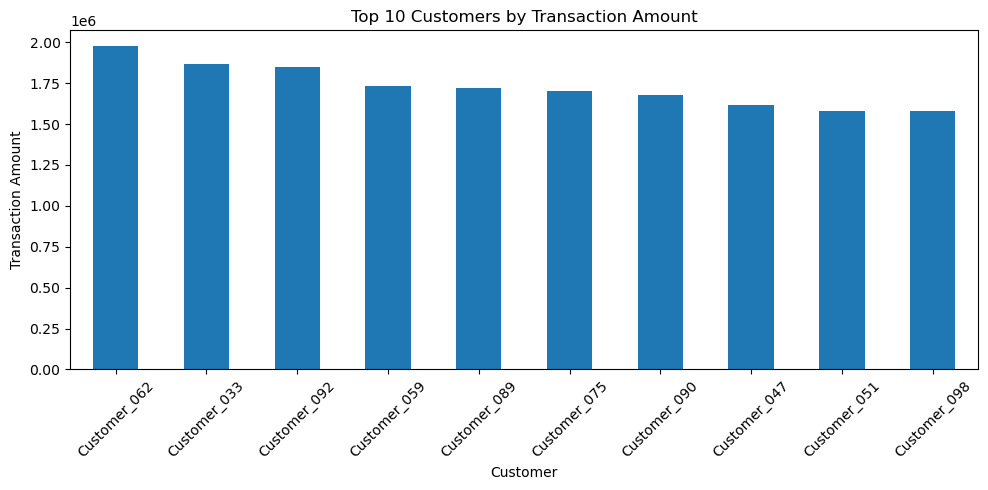

In [57]:
# Create a bar chart of the top ten customers

top_customers.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Customers by Transaction Amount")
plt.xlabel("Customer")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

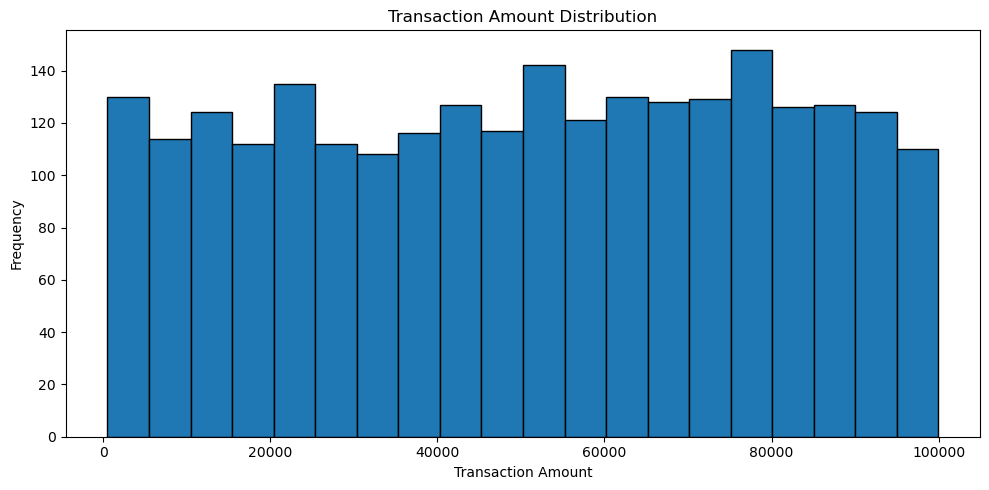

In [58]:
# Create a histogram

plt.figure(figsize=(10, 5))

plt.hist(
    df["Amount"],
    bins=20,
    edgecolor="black"
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [59]:
# Select the input and target columns

X = df[["Transaction_Count"]]

Y = df["Amount"]

# Display input data

print("Input data:")

print(X.head())

# Display target data

print("Target data:")

print(Y.head())

Input data:
   Transaction_Count
0                  2
1                  1
2                  2
3                  1
4                  2
Target data:
0    90599.72
1    77375.96
2    26857.10
3    64706.34
4    59777.20
Name: Amount, dtype: float64


In [60]:
# Split the data into training and testing sets

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)


In [61]:
# Create the Linear Regression model

model = LinearRegression()

In [64]:
# Train the model

model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
Y_pred=model.predict(X_test)
Y_pred

array([51066.94343253, 50685.08510966, 50557.79900204, 50939.65732491,
       50303.22678679, 50430.51289441, 50303.22678679, 51066.94343253,
       50685.08510966, 50939.65732491, 50557.79900204, 50685.08510966,
       50430.51289441, 50557.79900204, 50939.65732491, 50812.37121729,
       50557.79900204, 50685.08510966, 50557.79900204, 50175.94067917,
       50303.22678679, 50430.51289441, 50303.22678679, 51066.94343253,
       50939.65732491, 51066.94343253, 50685.08510966, 50685.08510966,
       50685.08510966, 50557.79900204, 50303.22678679, 50685.08510966,
       50430.51289441, 50430.51289441, 49921.36846392, 51066.94343253,
       50303.22678679, 50685.08510966, 50303.22678679, 50939.65732491,
       51066.94343253, 50303.22678679, 50303.22678679, 50685.08510966,
       50685.08510966, 50557.79900204, 50557.79900204, 50939.65732491,
       50685.08510966, 50812.37121729, 50303.22678679, 50685.08510966,
       50303.22678679, 50430.51289441, 50939.65732491, 50303.22678679,
      

In [66]:
# Predict transaction amounts

Y_pred = model.predict(X_test)

# Compare actual and predicted amounts

result = pd.DataFrame({
    "Actual_Amount": Y_test,
    "Predicted_Amount": Y_pred
})

print(result.head(10))

      Actual_Amount  Predicted_Amount
773        46927.47      51066.943433
261        22495.81      50685.085110
1076       68378.29      50557.799002
1784       74909.94      50939.657325
56         23122.05      50303.226787
908        47910.10      50430.512894
462        46286.15      50303.226787
1386       56118.57      51066.943433
1137       58429.77      50685.085110
1683       28908.12      50939.657325


In [67]:
# Calculate Mean Absolute Error

mae = mean_absolute_error(Y_test, Y_pred)

# Calculate Mean Squared Error

mse = mean_squared_error(Y_test, Y_pred)

# Calculate R-squared score

r2 = r2_score(Y_test, Y_pred)

# Display evaluation results

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

Mean Absolute Error: 25292.540815714434
Mean Squared Error: 858487047.6854349
R2 Score: -0.0003801829671794543


In [68]:
# Create new transaction data

new_data = pd.DataFrame({
    "Transaction_Count": [3]
})

# Predict the amount

future_amount = model.predict(new_data)

# Display the prediction

print("Predicted Transaction Amount:")
print(future_amount[0])

Predicted Transaction Amount:
50812.37121728568


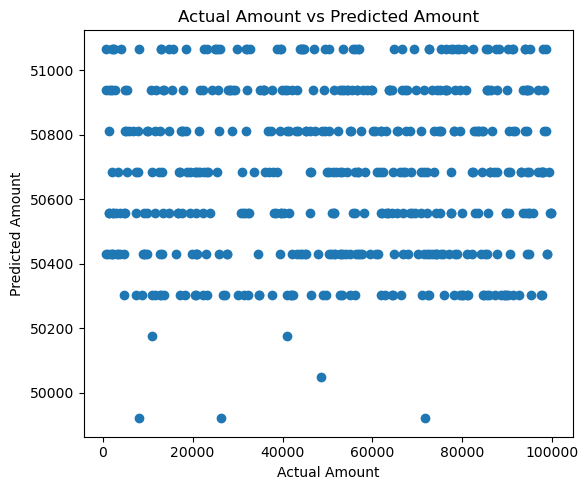

In [69]:
# Plot actual and predicted amounts

plt.figure(figsize=(6, 5))

plt.scatter(Y_test, Y_pred)

plt.xlabel("Actual Amount")
plt.ylabel("Predicted Amount")

plt.title("Actual Amount vs Predicted Amount")

plt.tight_layout()

plt.show()

In [70]:
# Select transaction amount for anomaly detection

fraud_data = df[["Amount"]]

# Create the Isolation Forest model

fraud_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Train the model and detect anomalies

df["Fraud_Prediction"] = fraud_model.fit_predict(
    fraud_data
)

# Select suspicious transactions

suspicious_transactions = df[
    df["Fraud_Prediction"] == -1
]

# Display suspicious transactions

print(suspicious_transactions.head(10))

    Transaction_ID      Customer    Amount  Transaction_Count  \
23           T0024  Customer_021  99550.31                  5   
35           T0036  Customer_080    623.05                  2   
37           T0038  Customer_062  98133.02                  4   
111          T0112  Customer_088    533.08                  5   
112          T0113  Customer_001   2259.94                  6   
196          T0197  Customer_003  98833.39                  1   
208          T0209  Customer_059  99163.05                  2   
209          T0210  Customer_032  97089.62                  3   
225          T0226  Customer_092   1537.56                  4   
253          T0254  Customer_073   1765.13                  6   

    Transaction_Category  Fraud_Prediction  
23            High Value                -1  
35             Low Value                -1  
37            High Value                -1  
111            Low Value                -1  
112            Low Value                -1  
196           

In [71]:
# Count potential anomalies

fraud_count = (
    df["Fraud_Prediction"] == -1
).sum()

print("Potential Anomalies:", fraud_count)

Potential Anomalies: 124


In [72]:
# Export the cleaned dataset

df.to_csv(
    "cleaned_transactions.csv",
    index=False
)

print("Cleaned dataset exported successfully")

Cleaned dataset exported successfully
